# 💡 **Nota Bene:** I will use GPU, not CPU

In [1]:
#@title Step 0: Check GPU Status
import subprocess
simple_nvidia_smi_display = True#@param {type:"boolean"}
if simple_nvidia_smi_display:
    #!nvidia-smi
    nvidiasmi_output = subprocess.run(['nvidia-smi', '-L'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
else:
    #!nvidia-smi -i 0 -e 0
    nvidiasmi_output = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_output)
    nvidiasmi_ecc_note = subprocess.run(['nvidia-smi', '-i', '0', '-e', '0'], stdout=subprocess.PIPE).stdout.decode('utf-8')
    print(nvidiasmi_ecc_note)

GPU 0: NVIDIA GeForce RTX 5090 (UUID: GPU-676d453f-8b5f-85a8-49c0-367df35e9146)



💡 **Nota Bene New:** I chose the Regression Problem Methodology because the predicted variable (SalePrice) consists of numerical values (home prices).

In [2]:
#@title Step 1: Import all necessary libraries for Mid Term 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns # for hot msp
import kagglehub
import kagglehub # for kaggle code in dataset https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset?resource=download

#@title Step 1.1: Import all necessary libraries for Final Exam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import BayesianRidge

# 💡 **Nota Bene:**  I will try code from Kaggle:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")

print("Path to dataset files:", path)

In [3]:
# Download latest version
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\poloz\.cache\kagglehub\datasets\shashanknecrothapa\ames-housing-dataset\versions\1


In [4]:
#@title Step 2: Load this Ames Housing dataset into memory

df = pd.read_csv('AmesHousing.csv')
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [5]:
#@title  Step 3: Split data into training set (70%) and testing set (30%)
# We use random_state to get the same split every time
train_data, test_data = train_test_split(df, test_size=0.30, random_state=42)


💡 **Nota Bene New:** changed requirements
Midterm requirements: “70% training, 30% testing”
Final exam requirements: “Split your data into Train (70%), Validation (15%), and Test (15%)” 

In [6]:
#@title Step 3.5: Split data into Train (70%), Validation (15%), and Test (15%)

# Ensure SalePrice_log exists in train_data
#if 'SalePrice_log' not in train_data.columns:
#    train_data['SalePrice_log'] = np.log1p(df.loc[train_data.index, 'SalePrice'])

# Separate features (only numeric) and target from training data
#X = train_data.select_dtypes(include=[np.number]).drop(columns=['SalePrice_log'], errors='ignore')
#y = train_data['SalePrice_log']

# First split: 70% Train, 30% Temporary (for Val & Test)
#X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Second split: Split the 30% evenly into 15% Validation and 15% Test
#X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Print split shapes to verify proportions
#print("--- Final Dataset Splits ---")
#print("Train set size:", X_train.shape[0])
#print("Validation set size:", X_val.shape[0])
#print("Test set size:", X_test.shape[0])

💡 **Nota Bene New:* I moved “Step 3.5” to “Step 8.6”

💡 **Nota Bene New:* The next part of the code also needs to be changed so that it displays “Three-Way Dataset Split Visualization” instead of “Two-Way Dataset Split Visualization.”

💡 **Nota Bene New:* I moved “Step 4” to “Step 8.7”

In [7]:
#@title Step 4: Print sizes
#print("--- Check Dataset Split ---")
#print("Original data shape:", df.shape)
#print("Training data shape (70%):", X_train.shape)
#print("Validation data shape (15%):", X_val.shape)
#print("Testing data shape (15%):", X_test.shape)
#print("\n")

# Data for plotting
#labels = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
#counts = [len(X_train), len(X_val), len(X_test)]
#3colors = ['#ff9999', '#ffcc99', '#66b3ff']

# Function to display count and percentage
#def make_autopct(values):
#    def my_autopct(pct):
#        total = sum(values)
#        val = int(round(pct*total/100.0))
#        return '{p:.1f}%\n({v:d} rows)'.format(p=pct, v=val)
#    return my_autopct

# Create a pie chart
#plt.figure(figsize=(7, 7))
#plt.pie(counts, labels=labels, autopct=make_autopct(counts), startangle=90, colors=colors)
#plt.title('Dataset Split Visualization')
#plt.show()

# 💡 **Nota Bene:**: I see a 30/70 split.
Also, this training set of over 2000.

In [8]:
#@title  Step 5: Find columns with missing values (NaN) only in training data
# Testing data must stay untouched
missing_values = train_data.isnull().sum()
missing_cols = missing_values[missing_values > 0].sort_values(ascending=False)

print("--- Columns with Missing Values in Train Data ---")
if not missing_cols.empty:
    for col, count in missing_cols.items():
        print(f"Column: {col} | Missing cells: {count} | Type: {train_data[col].dtype}")
else:
    print("No missing values found in this training dataset.")

--- Columns with Missing Values in Train Data ---
Column: Pool QC | Missing cells: 2041 | Type: str
Column: Misc Feature | Missing cells: 1969 | Type: str
Column: Alley | Missing cells: 1904 | Type: str
Column: Fence | Missing cells: 1642 | Type: str
Column: Mas Vnr Type | Missing cells: 1246 | Type: str
Column: Fireplace Qu | Missing cells: 1016 | Type: str
Column: Lot Frontage | Missing cells: 347 | Type: float64
Column: Garage Cond | Missing cells: 111 | Type: str
Column: Garage Yr Blt | Missing cells: 111 | Type: float64
Column: Garage Finish | Missing cells: 111 | Type: str
Column: Garage Qual | Missing cells: 111 | Type: str
Column: Garage Type | Missing cells: 109 | Type: str
Column: Bsmt Exposure | Missing cells: 55 | Type: str
Column: BsmtFin Type 2 | Missing cells: 54 | Type: str
Column: Bsmt Qual | Missing cells: 53 | Type: str
Column: BsmtFin Type 1 | Missing cells: 53 | Type: str
Column: Bsmt Cond | Missing cells: 53 | Type: str
Column: Mas Vnr Area | Missing cells: 14 | T

# 💡 **Nota Bene:**:  I don't analyze the test data, because, as far as our model is concerned, it doesn't exist yet

Before step 6:

In [9]:
#@title Step 5.5
print(train_data['Alley'].value_counts(dropna=False))

Alley
NaN     1904
Grvl      90
Pave      57
Name: count, dtype: int64


In [10]:
#@title Step 6: Fill NaN values using logical categories
# We make one copy to avoid pandas warnings
train_data = train_data.copy()

# Category 1: Missing text means this house does not have this feature (e.g., no pool, no alley)
cols_none = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu',
             'Garage Cond', 'Garage Finish', 'Garage Qual', 'Garage Type',
             'Bsmt Exposure', 'BsmtFin Type 2', 'Bsmt Qual', 'BsmtFin Type 1', 'Bsmt Cond']

for col in cols_none:
    train_data[col] = train_data[col].fillna('None')

# Category 2: Missing number means zero area or zero cars
cols_zero = ['Garage Yr Blt', 'Mas Vnr Area', 'BsmtFin SF 1', 'Bsmt Half Bath',
             'Total Bsmt SF', 'Bsmt Full Bath', 'BsmtFin SF 2', 'Bsmt Unf SF',
             'Garage Area', 'Garage Cars']

for col in cols_zero:
    train_data[col] = train_data[col].fillna(0)

print("--- Check Empty Cells after Step 6 ---")
print("Remaining NaN count:", train_data[cols_none + cols_zero].isnull().sum().sum())

--- Check Empty Cells after Step 6 ---
Remaining NaN count: 0


After step 6:

In [11]:
#@title Step 6.5:
print(train_data['Alley'].value_counts(dropna=False))

Alley
None    1904
Grvl      90
Pave      57
Name: count, dtype: int64


# 💡 **Nota Bene:**: NaN 1904 -> None 1904

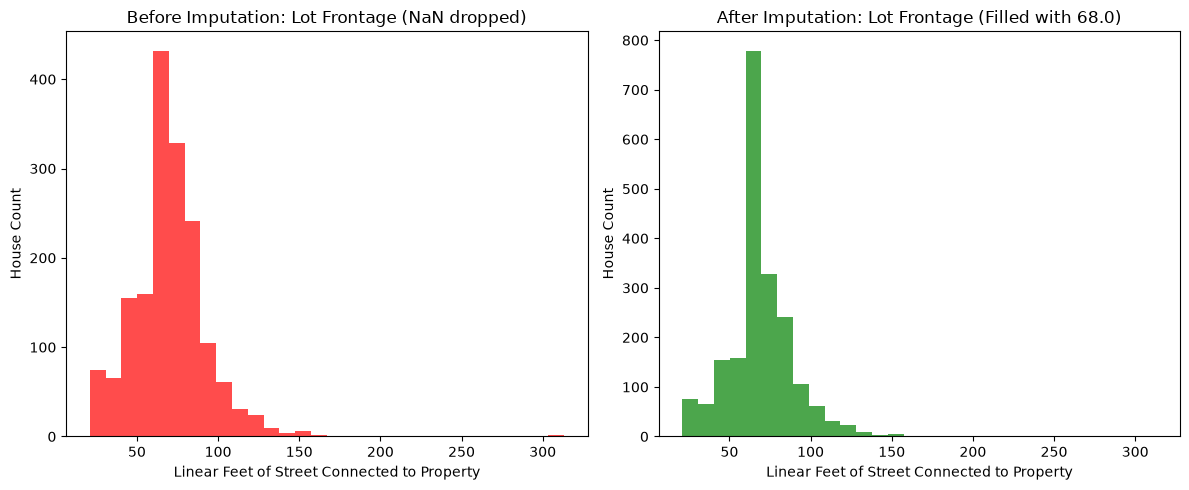

--- Check Lot Frontage Data ---
2210    82.0
782     65.0
2310    60.0
299     35.0
2423    68.0
Name: Lot Frontage, dtype: float64


In [12]:
#@title Step 7: Fill missing values with Median and plot with Matplotlib

# Save old data to plot "Before"
lot_frontage_before = train_data['Lot Frontage'].copy()

# Category 3: Fill missing physical measurements with median number
median_value = train_data['Lot Frontage'].median()
train_data['Lot Frontage'] = train_data['Lot Frontage'].fillna(median_value)

# Save new data to plot "After"
lot_frontage_after = train_data['Lot Frontage']

# Build Matplotlib plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Before
axes[0].hist(lot_frontage_before.dropna(), bins=30, color='red', alpha=0.7)
axes[0].set_title('Before Imputation: Lot Frontage (NaN dropped)')
axes[0].set_xlabel('Linear Feet of Street Connected to Property')
axes[0].set_ylabel('House Count')

# Plot 2: After
axes[1].hist(lot_frontage_after, bins=30, color='green', alpha=0.7)
axes[1].set_title(f'After Imputation: Lot Frontage (Filled with {median_value})')
axes[1].set_xlabel('Linear Feet of Street Connected to Property')
axes[1].set_ylabel('House Count')

plt.tight_layout()
plt.show()

# Print sample data
print("--- Check Lot Frontage Data ---")
print(train_data['Lot Frontage'].head())

# 💡 **Nota Bene:**:  The median is better than the average because it ignores very high outliers.

In [13]:
#@title Step 8: Feature Engineering and Encoding
# Create new feature: House Age
train_data['House_Age'] = train_data['Yr Sold'] - train_data['Year Built']

# Convert text categories to numbers (Simple One-Hot Encoding example)
# We choose a few important text columns to encode
train_data = pd.get_dummies(train_data, columns=['Street', 'Central Air'], drop_first=True)

# Encoding Ordinal data (Mapping quality text to numbers)
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
train_data['Exter Qual'] = train_data['Exter Qual'].map(qual_map)

print("--- Feature Engineering & Encoding Complete ---")
print("New columns:", train_data.columns[-5:].tolist())

--- Feature Engineering & Encoding Complete ---
New columns: ['Sale Condition', 'SalePrice', 'House_Age', 'Street_Pave', 'Central Air_Y']


In [14]:
train_data

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Alley,Lot Shape,Land Contour,Utilities,...,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,House_Age,Street_Pave,Central Air_Y
2210,2211,909275030,90,RH,82.0,6270,None,Reg,HLS,AllPub,...,None,0,8,2007,WD,Normal,145000,58,True,False
782,783,905325020,20,RL,65.0,25095,None,IR1,Low,AllPub,...,None,0,6,2009,WD,Partial,143000,41,True,True
2310,2311,527105060,60,RL,60.0,8238,None,IR1,Lvl,AllPub,...,None,0,5,2006,WD,Normal,183500,9,True,True
299,300,909455040,120,RM,35.0,3907,None,IR1,HLS,AllPub,...,None,0,3,2010,WD,Normal,162500,21,True,True
2423,2424,528228415,120,RM,68.0,3072,None,Reg,Lvl,AllPub,...,None,0,5,2006,WD,Normal,178740,2,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,1639,527226040,190,RL,195.0,41600,None,IR1,Lvl,AllPub,...,None,0,11,2007,WD,Normal,155000,38,True,True
1095,1096,528290090,60,RL,68.0,7750,None,Reg,Lvl,AllPub,...,None,0,4,2008,WD,Normal,176000,6,True,True
1130,1131,528490080,60,FV,64.0,8791,None,IR1,Lvl,AllPub,...,None,0,5,2008,WD,Normal,207500,5,True,True
1294,1295,902109160,50,RM,81.0,7308,None,Reg,Lvl,AllPub,...,None,0,6,2008,WD,Normal,122250,88,True,False


In [15]:
print(train_data[['Street_Pave', 'Central Air_Y']].head(10))

      Street_Pave  Central Air_Y
2210         True          False
782          True           True
2310         True           True
299          True           True
2423         True           True
1995         True           True
2177         True           True
1562         True           True
2229         True           True
1592         True           True


# 💡 **Nota Bene New:**: **Midterm Correction:** Visualizing Target Variable Transformation
The notebook performs log normalization but does not include a direct before/after histogram comparing salePrice and salePrice_log.
Suggest output after data transformation
- 2 points

Viswanatha Rao, Jul 14 at 2:51am

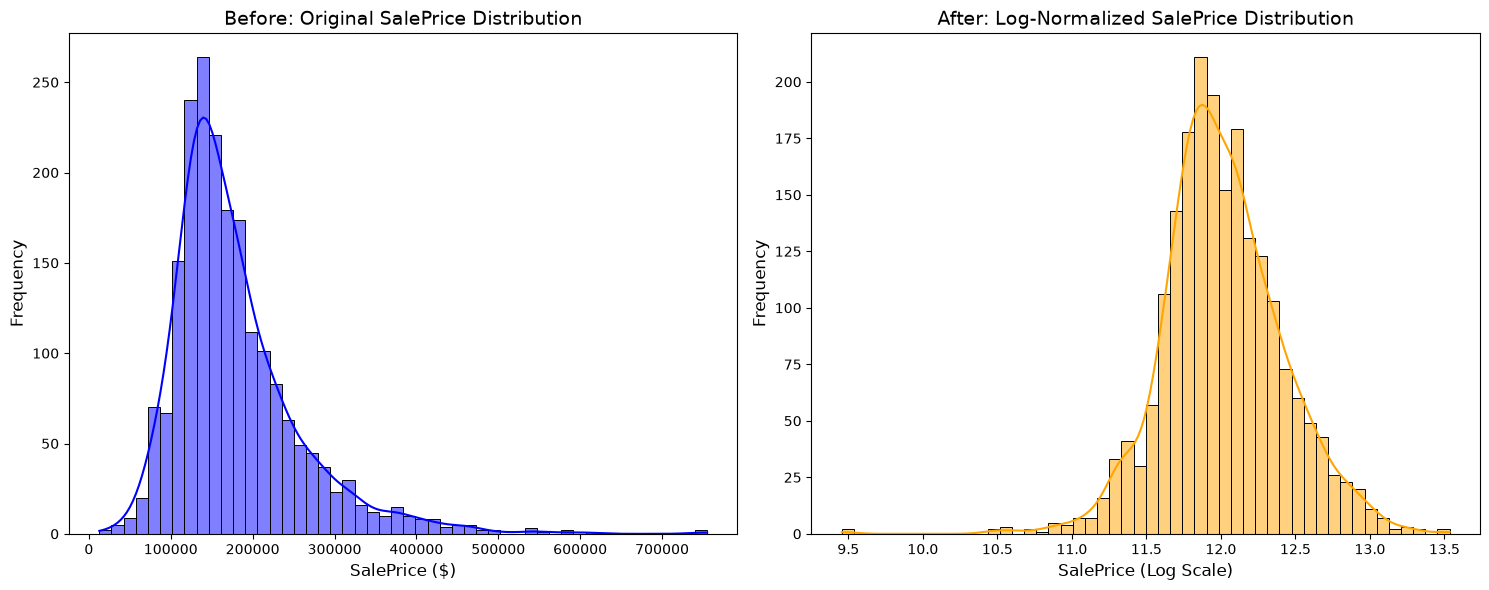

In [16]:
#@title Step 8.5: Midterm Correction

# Create a copy of the target variable for before/after comparison
target_before = train_data['SalePrice'].copy()

# log1p transformation
train_data['SalePrice_log'] = np.log1p(train_data['SalePrice'])
target_after = train_data['SalePrice_log']


test_data['SalePrice_log'] = np.log1p(test_data['SalePrice'])

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Before Normalization (Original SalePrice)
sns.histplot(target_before, bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Before: Original SalePrice Distribution', fontsize=14)
axes[0].set_xlabel('SalePrice ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Plot 2: After Normalization (Log-transformed SalePrice)
sns.histplot(target_after, bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('After: Log-Normalized SalePrice Distribution', fontsize=14)
axes[1].set_xlabel('SalePrice (Log Scale)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()


train_data = train_data.drop(columns=['SalePrice'])
test_data = test_data.drop(columns=['SalePrice'])

In [17]:
#@title Step 8.6: Split data into Train (70%), Validation (15%), and Test (15%)

# Separate numeric features and target from fully processed train_data
X = train_data.select_dtypes(include=[np.number]).drop(columns=['SalePrice_log', 'SalePrice'], errors='ignore')
y = train_data['SalePrice_log']

# First split: 70% Train, 30% Temporary (for Val & Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Second split: Split the 30% evenly into 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Print split shapes to verify proportions
print("--- Final Dataset Splits ---")
print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

--- Final Dataset Splits ---
Train set size: 1435
Validation set size: 308
Test set size: 308


--- Check Dataset Split ---
Original data shape: (2930, 82)
Training data shape (70%): (1435, 40)
Validation data shape (15%): (308, 40)
Testing data shape (15%): (308, 40)




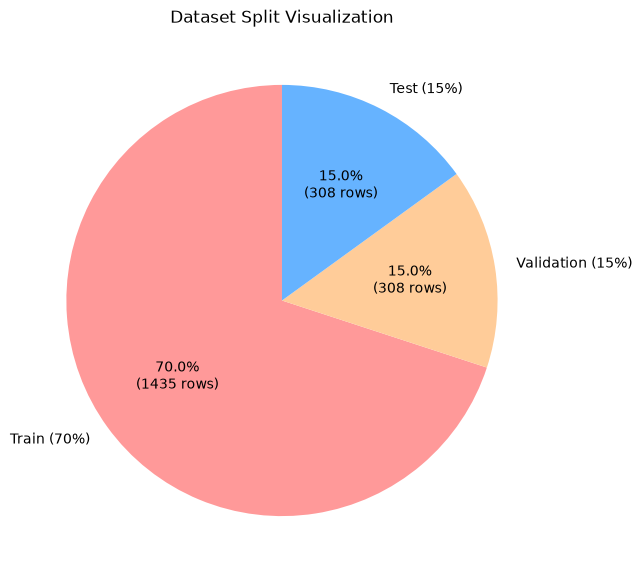

In [18]:
#@title Step 8.7: Print sizes
print("--- Check Dataset Split ---")
print("Original data shape:", df.shape)
print("Training data shape (70%):", X_train.shape)
print("Validation data shape (15%):", X_val.shape)
print("Testing data shape (15%):", X_test.shape)
print("\n")

# Data for plotting
labels = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
counts = [len(X_train), len(X_val), len(X_test)]
colors = ['#ff9999', '#ffcc99', '#66b3ff']

# Function to display count and percentage
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.1f}%\n({v:d} rows)'.format(p=pct, v=val)
    return my_autopct

# Create a pie chart
plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, autopct=make_autopct(counts), startangle=90, colors=colors)
plt.title('Dataset Split Visualization')
plt.show()

# 💡 **Nota Bene:**: I'll try using the hot map

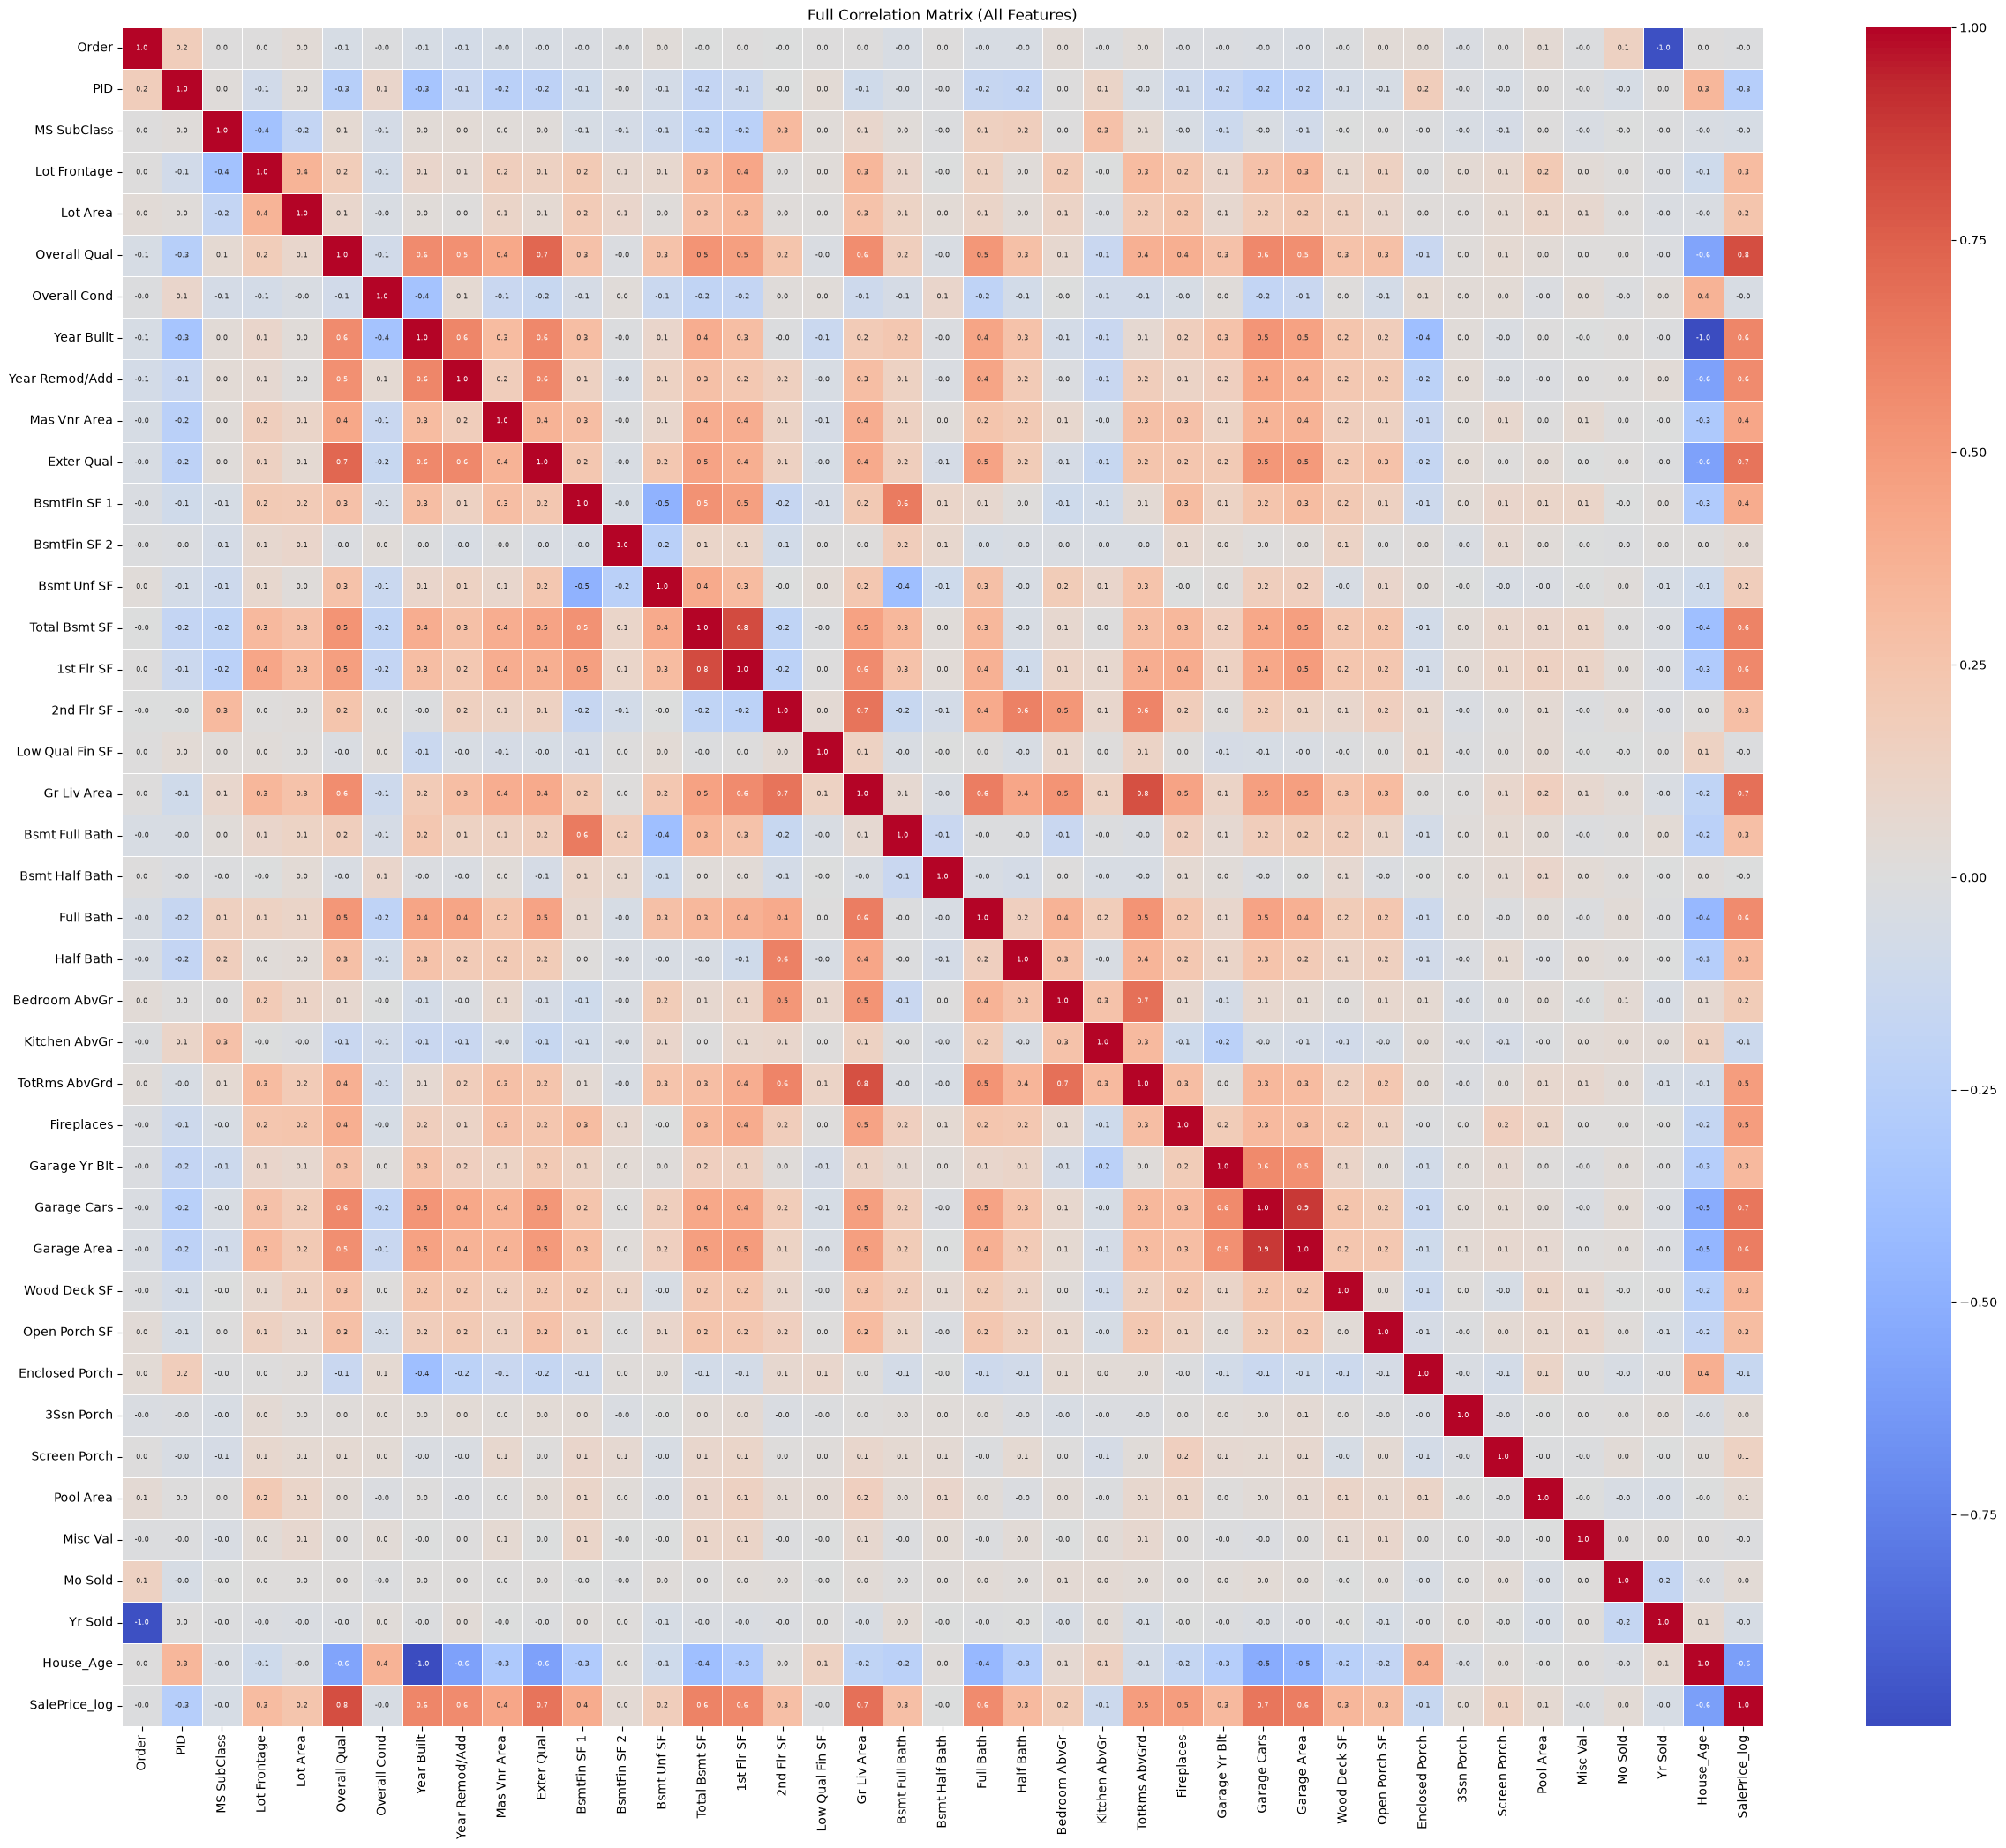

In [19]:
#@title Step 8.8: Hot map of correlation matrix for all numeric features
numeric_df = train_data.select_dtypes(include=[np.number])


full_corr = numeric_df.corr()

# Make hot map
plt.figure(figsize=(30, 25))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt=".1f",
            annot_kws={"size": 6}, linewidths=0.5)

plt.title('Full Correlation Matrix (All Features)')
plt.show()

# 💡 **Nota Bene:**:  There's too much data; I'll just include the correlation with price.

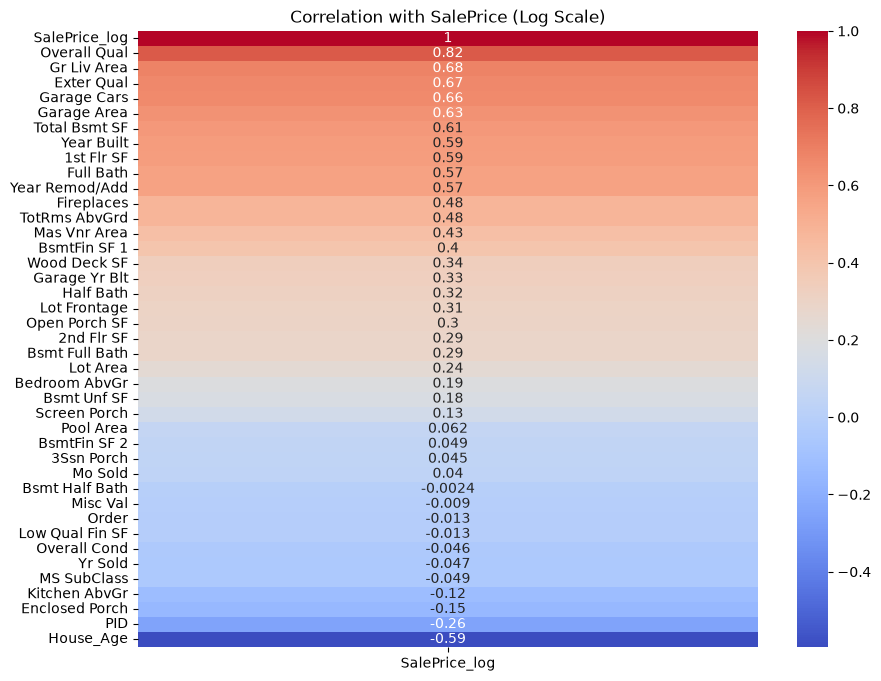

In [20]:
#@title Step 8.9: Correlation with SalePrice
numeric_df = train_data.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
# Replaced 'SalePrice' with 'SalePrice_log' to match our transformed target variable
sns.heatmap(numeric_df.corr()[['SalePrice_log']].sort_values(by='SalePrice_log', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with SalePrice (Log Scale)')
plt.show()

💡 **Nota Bene New:* After changing the project's midterm code, I had to make a few adjustments to the “Step 8.7: Correlation with SalePrice” cell as well.

In [21]:
#@title Step 9: Normalization, Scaling and Class Balancing
from sklearn.preprocessing import StandardScaler

# Convert boolean to integer (1 and 0) for ML
train_data['Street_Pave'] = train_data['Street_Pave'].astype(int)
train_data['Central Air_Y'] = train_data['Central Air_Y'].astype(int)

# Normalization: We already have SalePrice_log from Step 8.5, let's use it directly
# (No need to recreate it, but we can map it to SalePrice_Log if needed)
train_data['SalePrice_Log'] = train_data['SalePrice_log']

# Scaling: Change data range for large area metrics
scaler = StandardScaler()
cols_to_scale = ['Gr Liv Area', 'Lot Area']
train_data[cols_to_scale] = scaler.fit_transform(train_data[cols_to_scale])

# Class Balancing: Convert SalePrice_log to binary target using its median
median_price = train_data['SalePrice_log'].median()
train_data['Target'] = (train_data['SalePrice_log'] > median_price).astype(int)

# Balance classes using Undersampling
premium_houses = train_data[train_data['Target'] == 1]
standard_houses = train_data[train_data['Target'] == 0].sample(n=len(premium_houses), random_state=42)
final_df = pd.concat([premium_houses, standard_houses])

# Export Final Dataset
final_df.to_csv('Ames_Housing_Cleaned.csv', index=False)

print("--- Data Preprocessing Finalized ---")
print("Target Class Distribution:")
print(final_df['Target'].value_counts())

--- Data Preprocessing Finalized ---
Target Class Distribution:
Target
1    1011
0    1011
Name: count, dtype: int64


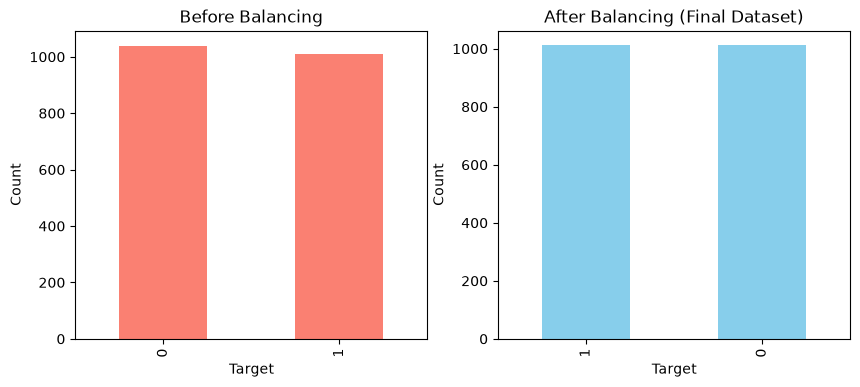

In [22]:
#@title Step 9.5: Visualizing Class Balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
train_data['Target'].value_counts().plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Before Balancing')
axes[0].set_ylabel('Count')

# After
final_df['Target'].value_counts().plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('After Balancing (Final Dataset)')
axes[1].set_ylabel('Count')

plt.show()

# 💡 **Nota Bene:**: I need to see more information

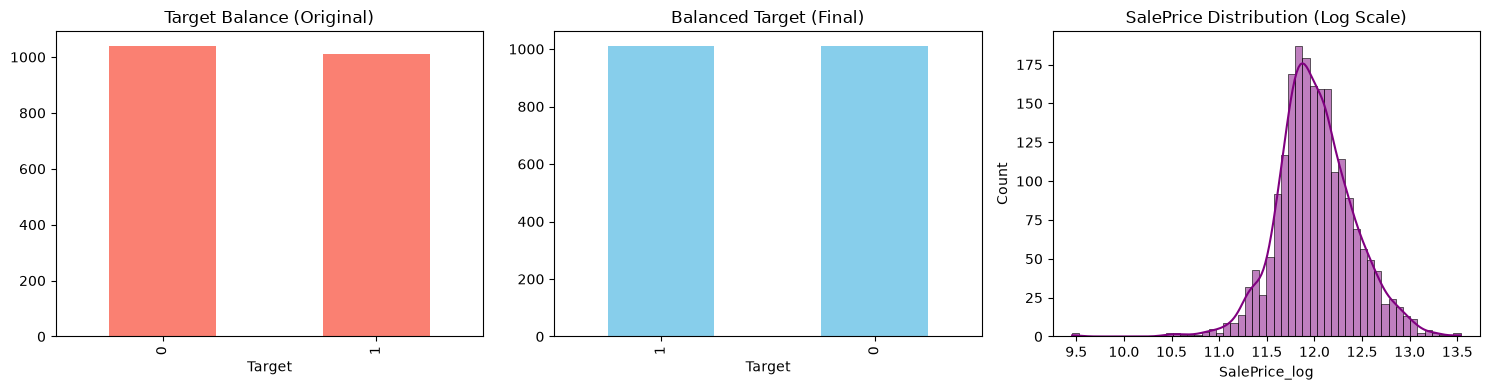

In [23]:
#@title Step 9.6: Visualizing Class Balance and SalePrice Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Target Balance (Before)
train_data['Target'].value_counts().plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Target Balance (Original)')

# 2. Final Dataset Balance (After)
final_df['Target'].value_counts().plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Balanced Target (Final)')

# 3. SalePrice Distribution (Using SalePrice_log since SalePrice was dropped)
sns.histplot(train_data['SalePrice_log'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('SalePrice Distribution (Log Scale)')

plt.tight_layout()
plt.show()

# 💡 **Nota Bene:** ML Problem Discussion
I will use this clean dataset to solve one classification problem. This dataset has many features like 'House_Age', 'Lot Area', and 'Street_Pave'. I want to build one ML model to predict premium houses.

First, I will change 'SalePrice' into one binary target (Premium or Standard). Next, I will balance these classes. This model can help real estate agents. They can use this model to predict if one new house gets premium status.

# 💡 **Nota Bene:** Final Actions Summary
I used log transform to normalize 'SalePrice' because this distribution had one big right skew. I used StandardScaler to change range for 'Gr Liv Area'. Finally, I created one binary target and balanced these classes with undersampling method. Testing data stays untouched. Clean CSV file is ready for GitHub.

--- Training Base Models ---
Linear Regression Validation RMSE: 0.1988
Decision Tree Validation RMSE: 0.2058
Random Forest Validation RMSE: 0.1281
Gradient Boosting Validation RMSE: 0.1099
KNN Validation RMSE: 0.2166


C:\Users\poloz\AppData\Local\Temp\ipykernel_59784\2825152251.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(val_metrics.keys()), y=list(val_metrics.values()), palette='viridis')


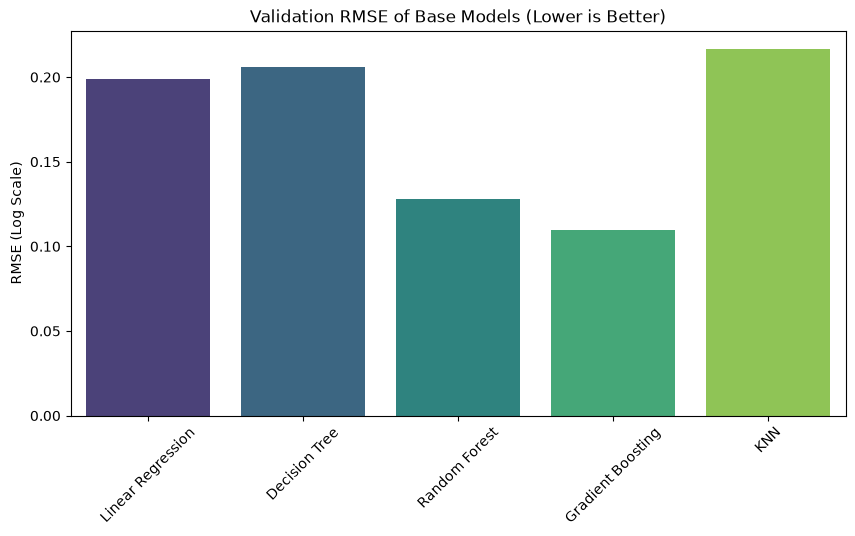

In [24]:
#@title Step 10: Train Base Regression Models

# Define a dictionary of models to train
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

# Dictionaries to store results
val_predictions = {}
test_predictions = {}
val_metrics = {}

print("--- Training Base Models ---")
for name, model in models.items():
    # Train model on training data
    model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Store predictions for ensembling
    val_predictions[name] = y_val_pred
    test_predictions[name] = y_test_pred
    
    # Calculate RMSE on validation set
    rmse = root_mean_squared_error(y_val, y_val_pred)
    val_metrics[name] = rmse
    
    print(f"{name} Validation RMSE: {rmse:.4f}")

# Visualize validation RMSE for base models
plt.figure(figsize=(10, 5))
sns.barplot(x=list(val_metrics.keys()), y=list(val_metrics.values()), palette='viridis')
plt.title('Validation RMSE of Base Models (Lower is Better)')
plt.ylabel('RMSE (Log Scale)')
plt.xticks(rotation=45)
plt.show()

💡 **Nota Bene New:** This error is not critical to execution

C:\Users\poloz\AppData\Local\Temp\ipykernel_40988\1438485513.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

In [25]:
#@title Step 10.5: Validate and Compare models (MAE, MSE, R² Score)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

metrics_data = []

print("--- Model Validation Performance ---")
for name, model in models.items():
    # Get predictions from the model
    y_val_pred = model.predict(X_val)
    
    # Calculate error scores
    mae = mean_absolute_error(y_val, y_val_pred)
    mse = mean_squared_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    
    # Save results in a list
    metrics_data.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'R² Score': r2
    })
    
    print(f"{name}: MAE={mae:.4f}, MSE={mse:.4f}, R²={r2:.4f}")

# Create a table for results
comparison_df = pd.DataFrame(metrics_data)
# Sort models from best to worst
comparison_df = comparison_df.sort_values(by='R² Score', ascending=False)

print("\n--- Comparison Table ---")
display(comparison_df)

--- Model Validation Performance ---
Linear Regression: MAE=0.1508, MSE=0.0395, R²=0.7726
Decision Tree: MAE=0.1456, MSE=0.0424, R²=0.7561
Random Forest: MAE=0.0881, MSE=0.0164, R²=0.9056
Gradient Boosting: MAE=0.0791, MSE=0.0121, R²=0.9304
KNN: MAE=0.1580, MSE=0.0469, R²=0.7299

--- Comparison Table ---


,Model,MAE,MSE,R² Score
3,Gradient Boosting,0.079107,0.012086,0.930428
2,Random Forest,0.088138,0.016407,0.905555
0,Linear Regression,0.150778,0.039505,0.772594
1,Decision Tree,0.145555,0.042368,0.756114
4,KNN,0.157961,0.046924,0.729890


💡 **Nota Bene New:** The “Random Forest” and “Gradient Boosting” and "Linear Regression" models look the best, so we'll use them in Step 11

In [26]:
#@title Step 11: Train Voting Regressor (Top 3 Models)

# Build voting regressor with top 3 models
voting_model = VotingRegressor(estimators=[
    ('gb', models['Gradient Boosting']),
    ('rf', models['Random Forest']),
    ('lr', models['Linear Regression'])
])

# Fit on train data
voting_model.fit(X_train, y_train)

# Predict and evaluate on validation set
y_val_pred_voting = voting_model.predict(X_val)
voting_r2 = r2_score(y_val, y_val_pred_voting)
voting_rmse = root_mean_squared_error(y_val, y_val_pred_voting)

print(f"Voting Regressor Validation R²: {voting_r2:.4f}")
print(f"Voting Regressor Validation RMSE: {voting_rmse:.4f}")

# Predict and evaluate on test set (REQUIRED)
y_test_pred_voting = voting_model.predict(X_test)
voting_test_r2 = r2_score(y_test, y_test_pred_voting)
voting_test_rmse = root_mean_squared_error(y_test, y_test_pred_voting)

print(f"Voting Regressor Test R²: {voting_test_r2:.4f}")
print(f"Voting Regressor Test RMSE: {voting_test_rmse:.4f}")

Voting Regressor Validation R²: 0.9083
Voting Regressor Validation RMSE: 0.1262
Voting Regressor Test R²: 0.8514
Voting Regressor Test RMSE: 0.1612


💡 **Nota Bene New:** This mix of two models (“Random Forest” and “Gradient Boosting” and Linear Regression) gives one good result. This score means our error is low, but for some reason, the Gradient Boosting model performs better.

Voting Regressor Validation R²: 0.9083

Voting Regressor Validation RMSE: 0.1262

Voting Regressor Test R²: 0.8514

Voting Regressor Test RMSE: 0.1612


Gradient Boosting Validation RMSE: 0.1099

Gradient Boosting R² Score 0.930428

In [27]:
#@title Step 12: Train Bayesian Ridge Ensemble and Compare

# Initialize and train Bayesian Ridge model
bayesian_model = BayesianRidge()
bayesian_model.fit(X_train, y_train)

# Predict and evaluate on Validation set
y_val_pred_bayes = bayesian_model.predict(X_val)
bayes_val_r2 = r2_score(y_val, y_val_pred_bayes)
bayes_val_rmse = root_mean_squared_error(y_val, y_val_pred_bayes)

# Predict and evaluate on Test set (Required!)
y_test_pred_bayes = bayesian_model.predict(X_test)
bayes_test_r2 = r2_score(y_test, y_test_pred_bayes)
bayes_test_rmse = root_mean_squared_error(y_test, y_test_pred_bayes)

print(f"Bayesian Ridge Validation R²: {bayes_val_r2:.4f}")
print(f"Bayesian Ridge Test R²: {bayes_test_r2:.4f}")

# Compare Voting Regressor vs Bayesian Ensemble
print("\n--- Ensemble Comparison (Test Set) ---")
print(f"Voting Regressor Test R²: {voting_test_r2:.4f}")
print(f"Bayesian Ridge Test R²: {bayes_test_r2:.4f}")

Bayesian Ridge Validation R²: 0.9193
Bayesian Ridge Test R²: 0.8790

--- Ensemble Comparison (Test Set) ---
Voting Regressor Test R²: 0.8514
Bayesian Ridge Test R²: 0.8790
